In [1]:
## Installation required
## In qbraid we need to run the cell everytime we open a new session

!pip install qiskit[visualization]
# Use the following if you are on MacOS/zsh
#!pip install 'qiskit[visualization]'==1.1.0
!pip install qiskit_ibm_runtime
!pip install qiskit_aer
!pip install matplotlib
!pip install pylatexenc
!pip install prototype-zne

In [2]:
!pip install --upgrade qiskit-aer

In [3]:
import qiskit
qiskit.__version__

'2.5.1'

In [4]:
## Import packages

#from math import pi
#import numpy as np
import time
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
#from qiskit.circuit import Gate
from qiskit_aer import AerSimulator, QasmSimulator
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit.visualization import plot_histogram

size = 4*4*8 #nb*h*k = 128
n = 5 #No. of key qubits to recover
x = 0 #x denotes the additional length of the key stream, other than key length, n. If key stream length is n+2, then x = 2
rnd = 200

V = QuantumRegister(size) #128
X = QuantumRegister(size) #128
qr = QuantumRegister(288)
t = QuantumRegister(3)

r_key = QuantumRegister(n, 'r_key')
rev_ks = QuantumRegister(size, 'rev_ks') #n+x
r_ancilla = QuantumRegister(size, 'r_ancilla') #n+x
r_output = QuantumRegister(1, name = 'r_output')

num_qubit = 2*size+288+3+n+2*size+1 #It represents the total of qubits required
cr = ClassicalRegister(n) #128
qc = QuantumCircuit(V, X, qr, t, r_key, rev_ks, r_ancilla, r_output, cr)

In [5]:
num_qubits = qc.num_qubits
print("Number of qubits:", num_qubits)

Number of qubits: 809


In [6]:
def key_gen2(qc, qr, V, round, ks):
    for i in range(round):        
        qc.cx(qr[65],qr[92])
        qc.ccx(qr[90],qr[91],qr[92])
        qc.cx(qr[170],qr[92])
        qc.swap(qr[92],t[0])
        
        qc.cx(qr[161],qr[176])
        qc.ccx(qr[174],qr[175],qr[176])
        qc.cx(qr[263],qr[176])
        qc.swap(qr[176],t[1])
        
        qc.cx(qr[242],qr[287])
        qc.ccx(qr[285],qr[286],qr[287])
        qc.cx(qr[68],qr[287])
        qc.swap(qr[287],t[2])

        for j in range(287,176,-1):
            if j == 177:
                qc.swap(qr[177], t[1])
            else:
                qc.swap(qr[j], qr[j-1])

        for j in range(176,92,-1):
            if j == 93:
                qc.swap(qr[93], t[0])
            else:
                qc.swap(qr[j], qr[j-1])
        
        for j in range(92,-1,-1):
            if j == 0:
                qc.swap(qr[0], t[2])
            else:
                qc.swap(qr[j], qr[j-1])


    """ Key Stream Generation """
    for i in range(ks):
        
        qc.cx(qr[65],qr[92])
        qc.swap(qr[92],t[0])
        
        qc.cx(qr[161],qr[176])
        qc.swap(qr[176],t[1])
        
        qc.cx(qr[242],qr[287])
        qc.swap(qr[287],t[2])
        
        qc.cx(t[0],V[i])
        qc.cx(t[1],V[i])
        qc.cx(t[2],V[i])
        
        qc.ccx(qr[90],qr[91],t[0]) 
        qc.cx(qr[170],t[0]) 
        
        qc.ccx(qr[174],qr[175],t[1]) 
        qc.cx(qr[263],t[1]) 
        
        qc.ccx(qr[285],qr[286],t[2]) 
        qc.cx(qr[68],t[2]) 
        
        for j in range(287,176,-1):
            if j == 177:
                qc.swap(qr[177], t[1])
            else:
                qc.swap(qr[j], qr[j-1])

        for j in range(176,92,-1):
            if j == 93:
                qc.swap(qr[93], t[0])
            else:
                qc.swap(qr[j], qr[j-1])
        
        for j in range(92,-1,-1):
            if j == 0:
                qc.swap(qr[0], t[2])
            else:
                qc.swap(qr[j], qr[j-1])
                

def rev_key_gen2(qc, qr, V, round, ks):

    for i in range(n):        
        for j in range(0,93,1): 
            if j == 0:
                qc.swap(qr[0], t[2])
            else:
                qc.swap(qr[j], qr[j-1])
                
        for j in range(93,177,1): 
            if j == 93:
                qc.swap(qr[93], t[0])
            else:
                qc.swap(qr[j], qr[j-1])
        
        for j in range(177,288,1): 
            if j == 177:
                qc.swap(qr[177], t[1])
            else:
                qc.swap(qr[j], qr[j-1])
        
        qc.cx(qr[68], t[2]) 
        qc.ccx(qr[285], qr[286], t[2]) 
        
        qc.cx(qr[263], t[1]) 
        qc.ccx(qr[174], qr[175], t[1]) 
        
        qc.cx(qr[170], t[0]) 
        qc.ccx(qr[90], qr[91], t[0]) 
        
        
        qc.cx(t[2], V[n-1-i])
        qc.cx(t[1], V[n-1-i])
        qc.cx(t[0], V[n-1-i])
        
        qc.swap(qr[287],t[2])
        qc.cx(qr[242],qr[287])
        
        qc.swap(qr[176],t[1])
        qc.cx(qr[161],qr[176])
        
        qc.swap(qr[92],t[0])
        qc.cx(qr[65],qr[92])
            
    
    for i in range(round):         
        for j in range(0,93,1):
            if j == 0:
                qc.swap(qr[0], t[2])
            else:
                qc.swap(qr[j], qr[j-1])
        
        for j in range(93,177,1):
            if j == 93:
                qc.swap(qr[93], t[0])
            else:
                qc.swap(qr[j], qr[j-1])
        
        for j in range(177,288,1):
            if j == 177:
                qc.swap(qr[177], t[1])
            else:
                qc.swap(qr[j], qr[j-1])
        
        qc.swap(qr[287],t[2])
        qc.cx(qr[68],qr[287])
        qc.ccx(qr[285],qr[286],qr[287])
        qc.cx(qr[242],qr[287])
        
        qc.swap(qr[176],t[1])
        qc.cx(qr[263],qr[176])
        qc.ccx(qr[174],qr[175],qr[176])
        qc.cx(qr[161],qr[176])
        
        qc.swap(qr[92],t[0])
        qc.cx(qr[170],qr[92])
        qc.ccx(qr[90],qr[91],qr[92])
        qc.cx(qr[65],qr[92])
        

In [7]:
def algo1_org(qc, V, X):
    nb = 4; delta = 2; H = 4; W = 8
    #pi1 = ??; pi2 = ??; pi3 = ??; pi4 = ??
    pi1=[2 for i in range(H)]; pi2=[2 for i in range(H)]  #some dummy values
    for j in range(1, nb+1):
        if j%delta == 0:
            #algo2_org(j, pi1, pi2, H, W)
            for h in range(1, H+1):
                for k in range(1, W+1):
                    index_x = (h - 1) * W + k
                    index1 = (j - 1) * H * W + (h-1) * W + k
                    index2 = (j - 1) * H * W + (pi1[h-1] - 1) * W + k
                    index3 = (j - 1) * H * W + (pi2[h-1] - 1) * W + k
                    qc.ccx(V[index1-1], X[index2-1], X[index_x-1])
                    qc.cx(V[index3-1], X[index_x-1])
                    qc.swap(V[index1-1], X[index_x-1])
        for h in range(1, H+1):
            for k in range(1, W+1):
                index_k = (h - 1) * W + k
                index1 = (j - 1) * H * W + (h - 1) * W + k
                index2 = (j - 1) * H * W + (pi1[h-1] - 1) * W + k
                qc.swap(V[index1-1], X[index_k-1])
                qc.cx(V[index2-1], X[index_k-1])
                index3 = (j - 1) * H * W + (pi2[h-1] - 1) * W + k
                qc.cx(V[index3-1], X[index_k-1])
        for h in range(1, H+1):
            for k in range(1, W+1):
                index_k = (h - 1) * W + k
                index_k1 = (h - 1) * W + (k - 2) % W #in place of 12
                qc.cx(X[index_k1-1], X[index_k-1])
                index_k2 = (h - 1) * W + (k + 5) % W #in place of 25
                index_k3 = (h - 1) * W + (k - 7) % W #in place of 27
                qc.cx(X[index_k2-1], X[index_k-1])
                qc.cx(X[index_k3-1], X[index_k-1])
                qc.swap(V[((j-1) * H * W + index_k)-1], X[index_k-1])
        for h in range(1, H+1):
            for k in range(1, W+1):
                index_x = (h - 1) * W + k
                index1 = (j - 1) * H * W + (h-1) * W + k
                index2 = (j - 1) * H * W + ((h - pi1[h-1]) % W) + k #in place of (j - 1) * H * W + ((h - pi1[h-1]) % W - 1) * W + k
                qc.swap(V[index2-1], X[index_x-1])
                qc.swap(V[index1-1], X[index_x-1])
                qc.swap(V[index2-1], X[index_x-1])


def algo1_org_rev(qc, V, X):
    nb = 4; delta = 2; H = 4; W = 8
    #pi1 = ??; pi2 = ??; pi3 = ??; pi4 = ??
    pi1=[2 for i in range(H)]; pi2=[2 for i in range(H)]  #some dummy values
    for j in range(nb, 0, -1): # it was (1, nb+1)
        for h in range(H, 0, -1): # it was (1, H+1)
            for k in range(W, 0, -1): # it was (1, W+1)
                index_x = (h - 1) * W + k
                index1 = (j - 1) * H * W + (h-1) * W + k
                index2 = (j - 1) * H * W + ((h - pi1[h-1]) % W) + k #in place of (j - 1) * H * W + ((h - pi1[h-1]) % W - 1) * W + k
                qc.swap(V[index2-1], X[index_x-1])
                qc.swap(V[index1-1], X[index_x-1])
                qc.swap(V[index2-1], X[index_x-1])
        for h in range(H, 0, -1): # it was (1, H+1)
            for k in range(W, 0, -1): # it was (1, W+1)
                index_k = (h - 1) * W + k
                index_k1 = (h - 1) * W + (k - 2) % W #in place of 12
                index_k2 = (h - 1) * W + (k + 5) % W #in place of 25
                index_k3 = (h - 1) * W + (k - 7) % W #in place of 27
                qc.swap(V[((j-1) * H * W + index_k)-1], X[index_k-1])
                qc.cx(X[index_k3-1], X[index_k-1])
                qc.cx(X[index_k2-1], X[index_k-1])
                qc.cx(X[index_k1-1], X[index_k-1])
        for h in range(H, 0, -1): # it was (1, H+1)
            for k in range(W, 0, -1): # it was (1, W+1)
                index_k = (h - 1) * W + k
                index1 = (j - 1) * H * W + (h - 1) * W + k
                index2 = (j - 1) * H * W + (pi1[h-1] - 1) * W + k
                index3 = (j - 1) * H * W + (pi2[h-1] - 1) * W + k                
                qc.cx(V[index2-1], X[index_k-1])
                qc.cx(V[index3-1], X[index_k-1])
                qc.swap(V[index1-1], X[index_k-1])              
        if j%delta == 0:
            #algo2_org(j, pi1, pi2, H, W)
            for h in range(H, 0, -1): # it was (1, H+1)
                for k in range(W, 0, -1): # it was (1, W+1)
                    index_x = (h - 1) * W + k
                    index1 = (j - 1) * H * W + (h-1) * W + k
                    index2 = (j - 1) * H * W + (pi1[h-1] - 1) * W + k
                    index3 = (j - 1) * H * W + (pi2[h-1] - 1) * W + k
                    qc.swap(V[index1-1], X[index_x-1])
                    qc.ccx(V[index1-1], X[index2-1], X[index_x-1])
                    qc.cx(V[index3-1], X[index_x-1])


In [8]:
#V_inp = "00001111"*16
#V_inp = "10011101110001010100111011111110100011010000010100011011011001001010000111001000000101101110110111001010100111000010011100111101"
#V_inp = "00000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000"
#V_inp = "11111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111"

#V_inp = "11100001110001010100111011111110100011010000010100011011011001001010000111001000000101101000110111001010000101000010011100111101"
#V_inp = "00110011001001111101010100001001010010010100111001011011111101110000111101000001100011010010000010001111100100000001000101110111"

V_inp = "011001001111101010100001001010010010100111001011011111101110000111101000001100011010010000010001111100100000001000101110111"

def V_init(qc, V, n, x):
    for i in range(size-(n+x)):
        if(V_inp[i] =="1"):
            qc.x(V[i+(n+x)])

In [9]:
def my_oracle(qc, r_key, r_ancilla, rev_ks, V, r_output, n, rnd, x):
    #Preparing key in a superposition state
    for i in range(n): #For loading partial key
        qc.cx(r_key[i], qr[36+i])
    key_gen2(qc, qr, V, rnd, n+x)
    algo1_org(qc, V, X)
    
    #Checking whether the generated key stream is equal to the given key stream
    for i in range(size):
        qc.cx(rev_ks[i], r_ancilla[i])
        qc.cx(V[i], r_ancilla[i]) 
        qc.x(r_ancilla[i])
        
    #Set 'output' bit if the key stream is matched
    qc.mcx(r_ancilla, r_output)
    
    qc.barrier()
    
    #Uncompute to reset ancilla & key stream qubits
    for i in range(size):
        qc.x(r_ancilla[i])
        qc.cx(rev_ks[i], r_ancilla[i])
        qc.cx(V[i], r_ancilla[i]) 
    qc.barrier()
    
    algo1_org_rev(qc, V, X)
    rev_key_gen2(qc, qr, V, rnd, n+x)
    for i in range(n):
        qc.cx(r_key[i], qr[36+i])
    qc.barrier()
        

In [10]:
#The diffuser function is available in Qiskit; Courtesey: https://github.com/Qiskit/textbook/blob/main/notebooks/ch-algorithms/grover.ipynb
def diffuser(nqubits):
    qc = QuantumCircuit(nqubits)
    #nqubits = nqubits - 2
    #Apply transformation |s> -> |00...0> (H gates)
    for qubit in range(nqubits):
        qc.h(qubit)
    #Apply transformation |00...0> -> |11...1> (X gates)
    for qubit in range(nqubits):
        qc.x(qubit)    
    #Do multi-controlled Z gate
    qc.h(nqubits - 1)
    qc.mcx(list(range(nqubits - 1)), nqubits - 1) #multi-controlled Toffoli; replaced with qc.mct(list(range(nqubits - 1)), nqubits - 1)
    qc.h(nqubits - 1)
    #Apply transformation |11...1> -> |00...0> (X gates)
    for qubit in range(nqubits):
        qc.x(qubit)
    #Apply transformation |00...0> -> |s> (H gates)
    for qubit in range(nqubits):
        qc.h(qubit)
    #We will return the diffuser as a gate
    U_s = qc.to_gate()
    #U_s.name = "U$_s$"
    return U_s

In [11]:
#loading known key stream for Key 
# For 200 rounds
ks_actual = '11000110010101011011111111111010011101001011010100100101000111111000100000011100001000100001000110000010001110110110101000010110'
# Actual Key: '00000'

for i in range(size):
    if (ks_actual[i] == "1"):
        qc.x(rev_ks[i])

for i in range(n):
    qc.h(r_key[i])

#Preparing output qubit
qc.x(r_output)
qc.h(r_output)
qc.barrier()

start = time.perf_counter() #time.process_time()

### Initialization of s array ###
key_0_35 = '000000010010001101000101011001111000' #len=36
key_41_79 = '010101111001101111011110001001000110100' #len=39
for i in range(36): #For loading Key
    if (key_0_35[i] == "1"):
        qc.x(qr[i+0]) 
for i in range(39): #For loading Key
    if (key_41_79[i] == "1"):
        qc.x(qr[i+41])

iv = '00000001001000110100010101100111100010011010101111001101111011110001001000110100'
for i in range(80): #For loading IV
    if (iv[i] == "1"):
        qc.x(qr[i+93]) 

qc.x(qr[285])
qc.x(qr[286])
qc.x(qr[287])
### End of Initialization ###
V_init(qc, V, n, x)
for i in range(2):
    my_oracle(qc, r_key, r_ancilla, rev_ks, V, r_output, n, rnd, x)
    #qc.barrier()
    qc.append(diffuser(n), r_key)
    #qc.barrier()

qc.measure(r_key, cr) 
print("Circuit depth: ", qc.depth())


Circuit depth:  80820


In [12]:
# Simulate the quantum circuit
backend = AerSimulator(method='matrix_product_state') # 'automatic' or 'matrix_product_state', 'density_matrix' (but only 'matrix_product_state' is working for select = 7; for other options simulation fails)
n_o_shots = 1024
tcirc = transpile(qc)
#qcd = qc.decompose(reps=5)
qcd = tcirc.decompose(reps=5) # Use this in place of above when we use 'tcirc = transpile(qc)'
result = backend.run(qcd, shots=n_o_shots).result() 
print("Wall-time elapsed (in sec):", time.perf_counter() - start)
## Plot results
counts = result.get_counts()
print (counts)

Wall-time elapsed (in sec): 1801.9487328999676
{'11001': 11, '00000': 608, '01111': 18, '00110': 13, '00100': 12, '01101': 10, '01001': 19, '00111': 13, '00010': 8, '11010': 15, '10100': 24, '01010': 18, '10110': 12, '11100': 11, '10101': 12, '10011': 11, '10111': 12, '00001': 14, '10000': 16, '01110': 20, '11101': 10, '01100': 15, '01000': 13, '11011': 11, '11111': 13, '10010': 12, '00101': 12, '00011': 12, '11000': 14, '11110': 12, '10001': 12, '01011': 11}


Key is : 00000 with probability = 0.59375 and count = 608


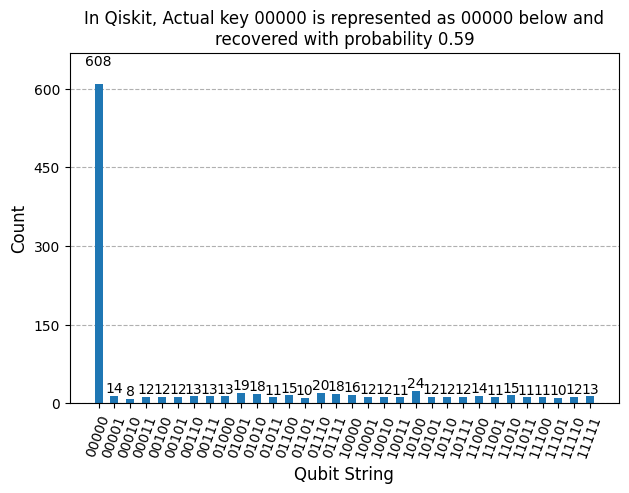

In [13]:
b, c = max(counts.items(), key=lambda x: x[1])
print("Key is :", b[::-1], "with probability =", c/n_o_shots, "and count =", c)

%matplotlib inline
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

figure = plot_histogram(counts, title = "In Qiskit, Actual key {0} is represented as {1} below and\nrecovered with probability {2:.2f}".format(b[::-1],b,c/n_o_shots))
# Label the axes
ax = figure.gca()  # Get the current axis
ax.set_xlabel('Qubit String', fontsize=12)  # Set x-axis label
ax.set_ylabel('Count', fontsize=12)  # Set y-axis label

# Save the plot as an image
figure.savefig("histogram.png")